In [5]:
# Crop Recommendation System using Machine Learning
# Thesis Project - Smart Agriculture in Bangladesh

print("Crop Recommendation System")
print("Thesis Project - Smart Agriculture in Bangladesh")

Crop Recommendation System
Thesis Project - Smart Agriculture in Bangladesh


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/SPAS-Dataset-BD.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (4608, 15)


,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity
0,177321,0.8510272331,Bagerhat,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,150905,40,12.0,60,85
1,25646,1.175777899,Bandarban,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,30154,40,12.0,60,85
2,231401,0.7705887183,Barguna,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,178315,40,12.0,60,85
3,302665,0.7571043893,Barishal,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,229149,40,12.0,60,85
4,388575,1.100652384,Bhola,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,427686,40,12.0,60,85


In [9]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area                   4608 non-null   int64  
 1   AP Ratio               4608 non-null   object 
 2   District               4608 non-null   object 
 3   Season                 4607 non-null   object 
 4   Avg Temp               4608 non-null   float64
 5   Avg Humidity           4608 non-null   float64
 6   Crop Name              4608 non-null   object 
 7   Transplant             4608 non-null   object 
 8   Growth                 4608 non-null   object 
 9   Harvest                4608 non-null   object 
 10  Production           

In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Area                     0
AP Ratio                 0
District                 0
Season                   1
Avg Temp                 0
Avg Humidity             0
Crop Name                0
Transplant               0
Growth                   0
Harvest                  0
Production               0
Max Temp                 0
Min Temp                 0
Max Relative Humidity    0
Min Relative Humidity    0
dtype: int64

Duplicate rows:
0


In [11]:
df["Season"] = df["Season"].fillna(df["Season"].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [12]:
print("Number of unique crops:", df["Crop Name"].nunique())

print("\nCrop names:")
print(df["Crop Name"].unique())

print("\nSamples per crop:")
print(df["Crop Name"].value_counts())

Number of unique crops: 73

Crop names:
['Aman' 'Amra' 'Arhar' 'Aus' 'Banana' 'Barbati' 'Beans' 'Betelnut'
 'Black Berry' 'Boro' 'Boroi' 'Cabbage' 'Carrot' 'Cauliflower' 'Chalkumra'
 'Cheena' 'Chili' 'Cucumber' 'Dalim' 'Danta' 'Danta Shak' 'Date Palm'
 'Garlic' 'Ginger' 'Gourd' 'Gram' 'Green Coconut' 'Green Palmyra'
 'Green Papaya' 'Groundnut' 'Guava' 'Jack Fruit' 'Jambura' 'Jamrul'
 'Jhinga' 'Jute' 'Kakrol' 'Karala' 'Kolmi Shak' 'Lady’s Finger' 'Lal Shak'
 'Laushak' 'Lemon' 'Lentil' 'Maize 1' 'Maize 2' 'Malta' 'Mango'
 'Mashkalai' 'Motor' 'Mug' 'Mukhi Kachu' 'Oal Kachu' 'Onion'
 'Palmyra Palm' 'Palong Shak' 'Patal' 'Pineapple' 'Puishak' 'Pumpkin'
 'Radish' 'Rape & Mustard' 'Ripe Papaya' 'Safeda' 'Sesame' 'Shalgom'
 'Sugarcane' 'Sweet Potato' 'Taramind' '#REF!' 'Tobacco' 'Wheat'
 'Wood Apple']

Samples per crop:
Crop Name
Aman          64
Amra          64
Arhar         64
Aus           64
Banana        64
              ..
Tobacco       64
Wood Apple    64
Wheat         64
Taramind     

In [13]:
df = df[df["Crop Name"] != "#REF!"].copy()

print("Dataset shape after cleaning:", df.shape)
print("Unique crops:", df["Crop Name"].nunique())

Dataset shape after cleaning: (4607, 15)
Unique crops: 72


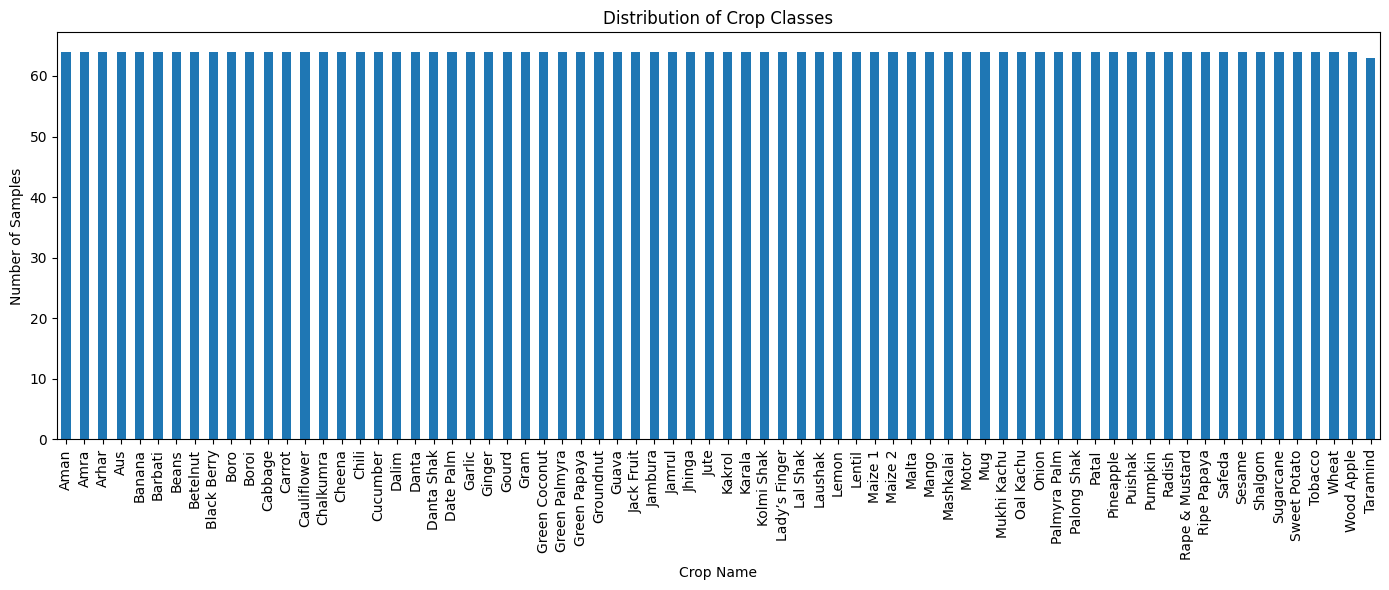

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df["Crop Name"].value_counts().plot(kind="bar")

plt.title("Distribution of Crop Classes")
plt.xlabel("Crop Name")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

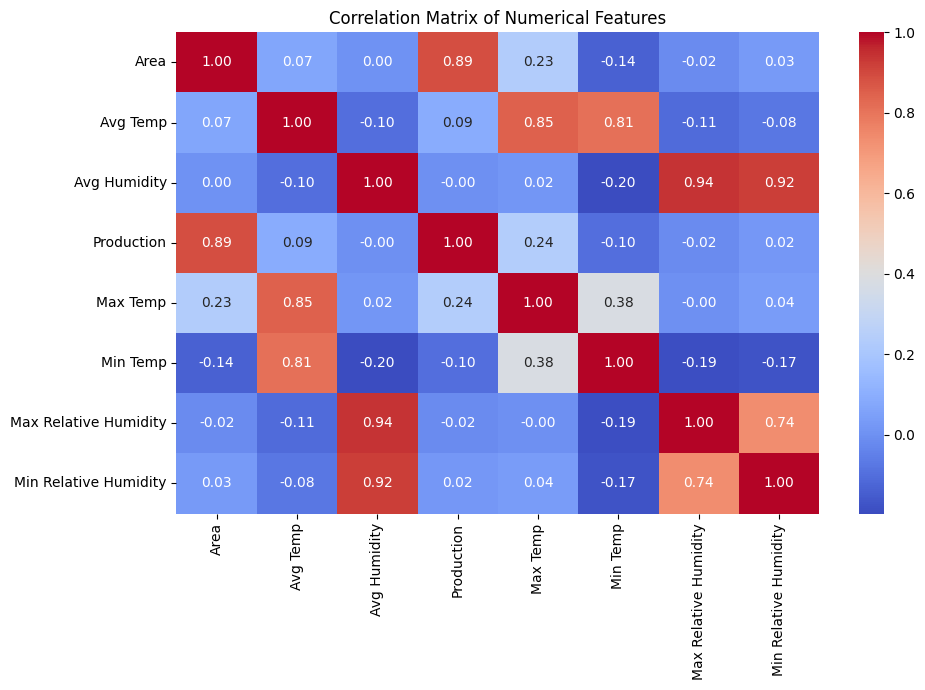

In [15]:
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))

correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [16]:
X = df.drop("Crop Name", axis=1)
y = df["Crop Name"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity', 'Transplant', 'Growth', 'Harvest', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity']

Target:
Crop Name


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3685
Testing samples: 922


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['AP Ratio', 'District', 'Season', 'Transplant', 'Growth', 'Harvest']
Numeric features: ['Area', 'Avg Temp', 'Avg Humidity', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity']


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (3685, 3304)
Encoded testing shape: (922, 3304)


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_encoded, y_train)

y_pred_dt = dt_model.predict(X_test_encoded)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 95.44 %


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 95.12 %


In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_encoded, y_train)

y_pred_knn = knn_model.predict(X_test_encoded)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 30.59 %


In [23]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_encoded, y_train)

y_pred_svm = svm_model.predict(X_test_encoded)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 5.64 %


In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train_encoded, y_train)

y_pred_lr = lr_model.predict(X_test_encoded)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 12.8 %


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


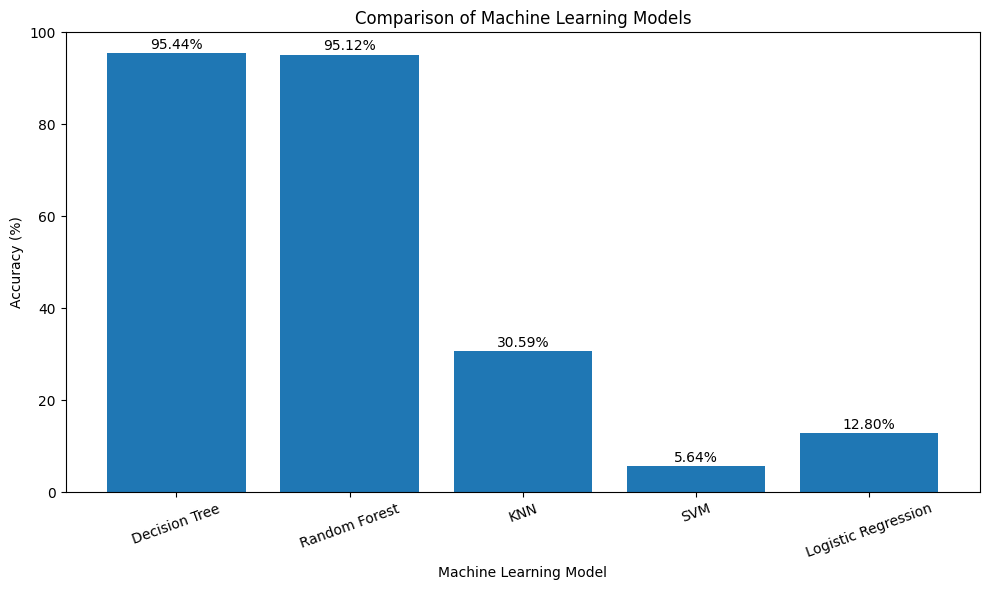

In [25]:
import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "KNN",
    "SVM",
    "Logistic Regression"
]

accuracies = [
    dt_accuracy * 100,
    rf_accuracy * 100,
    knn_accuracy * 100,
    svm_accuracy * 100,
    lr_accuracy * 100
]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 1, f"{accuracy:.2f}%", ha="center")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

                precision    recall  f1-score   support

          Aman       1.00      1.00      1.00        12
          Amra       0.75      0.69      0.72        13
         Arhar       1.00      1.00      1.00        13
           Aus       1.00      1.00      1.00        13
        Banana       1.00      1.00      1.00        12
       Barbati       1.00      1.00      1.00        13
         Beans       1.00      1.00      1.00        13
      Betelnut       1.00      1.00      1.00        13
   Black Berry       1.00      1.00      1.00        13
          Boro       1.00      1.00      1.00        12
         Boroi       1.00      1.00      1.00        12
       Cabbage       1.00      1.00      1.00        13
        Carrot       1.00      1.00      1.00        12
   Cauliflower       1.00      1.00      1.00        13
     Chalkumra       1.00      1.00      1.00        13
        Cheena       1.00      1.00      1.00        13
         

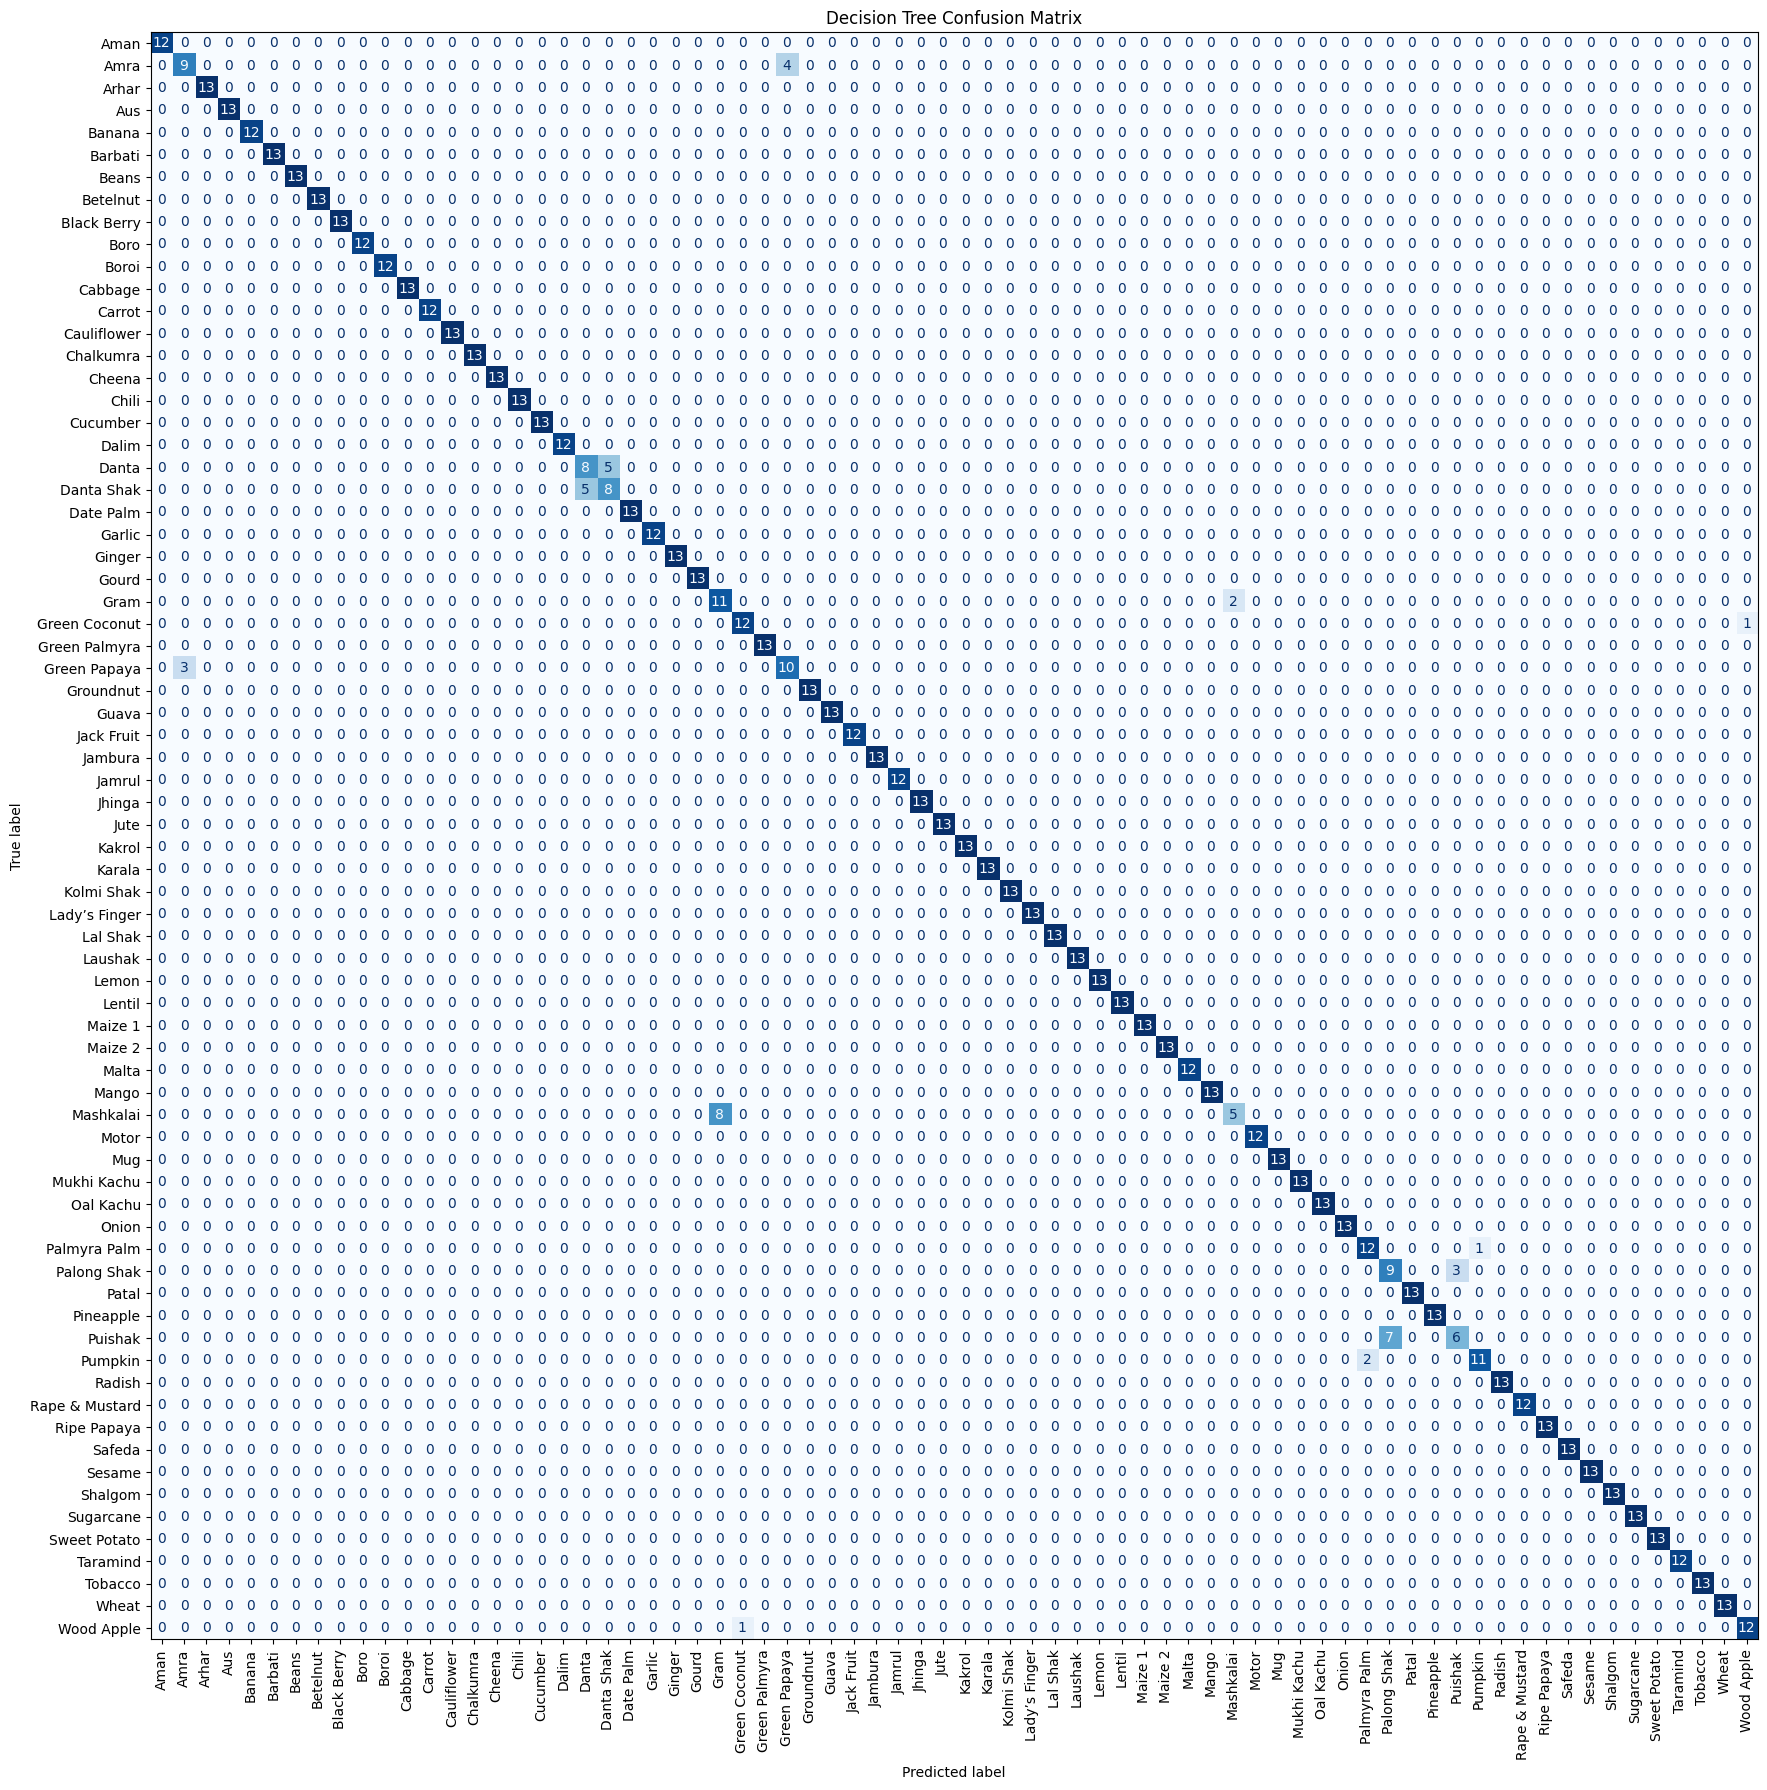

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt, labels=dt_model.classes_)

plt.figure(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

disp.plot(
    xticks_rotation=90,
    ax=plt.gca(),
    cmap="Blues",
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best Cross-Validation Accuracy:
96.26 %


In [29]:
best_dt = grid_search.best_estimator_

y_pred_best_dt = best_dt.predict(X_test_encoded)

best_dt_accuracy = accuracy_score(y_test, y_pred_best_dt)

print("Tuned Decision Tree Test Accuracy:",
      round(best_dt_accuracy * 100, 2), "%")

Tuned Decision Tree Test Accuracy: 96.1 %


In [30]:
from sklearn.metrics import classification_report

print("Tuned Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_best_dt))

Tuned Decision Tree Classification Report:

                precision    recall  f1-score   support

          Aman       1.00      1.00      1.00        12
          Amra       0.77      0.77      0.77        13
         Arhar       1.00      1.00      1.00        13
           Aus       1.00      1.00      1.00        13
        Banana       1.00      1.00      1.00        12
       Barbati       1.00      1.00      1.00        13
         Beans       1.00      1.00      1.00        13
      Betelnut       1.00      1.00      1.00        13
   Black Berry       1.00      1.00      1.00        13
          Boro       1.00      1.00      1.00        12
         Boroi       1.00      1.00      1.00        12
       Cabbage       1.00      1.00      1.00        13
        Carrot       1.00      1.00      1.00        12
   Cauliflower       1.00      1.00      1.00        13
     Chalkumra       1.00      1.00      1.00        13
        Cheena       1.00      1.00      1.00        13
   

In [31]:
# Feature Importance

feature_names = preprocessor.get_feature_names_out()
importances = best_dt.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                             Feature  Importance
3297                   num__Avg Temp    0.072046
3302      num__Max Relative Humidity    0.071907
3298               num__Avg Humidity    0.057903
3303      num__Min Relative Humidity    0.057832
3300                   num__Max Temp    0.057414
3299                 num__Production    0.054725
3301                   num__Min Temp    0.043108
3221            cat__Transplant_June    0.028955
3258          cat__Growth_Oct to Nov    0.028707
3230        cat__Growth_April to Aug    0.028707
3296                       num__Area    0.020577
3240        cat__Growth_July to  Oct    0.014632
3273  cat__Harvest_February to March    0.014632
3254          cat__Growth_Nov to Jan    0.014493
3241      cat__Growth_July to August    0.014492
3295  cat__Harvest_Throuout The year    0.014492
3237        cat__Growth_Dec to March    0.014492
3275                cat__Harvest_Jan    0.014492
3283              cat__Harvest_March    0.014492
3253          cat__G

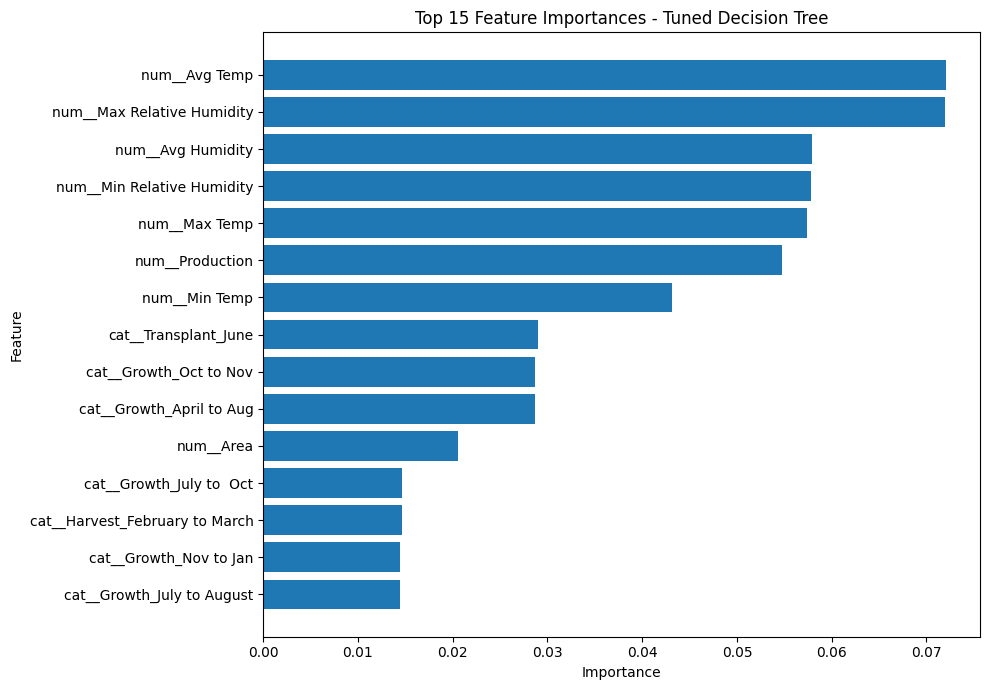

In [32]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Feature Importances - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [34]:
import joblib

# Save preprocessing and tuned model
joblib.dump(preprocessor, "crop_preprocessor.pkl")
joblib.dump(best_dt, "crop_recommendation_model.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [35]:
# Take one sample from the test set
sample = X_test.iloc[[0]]

# Predict crop
prediction = best_dt.predict(preprocessor.transform(sample))

print("Recommended Crop:", prediction[0])

Recommended Crop: Garlic


In [36]:
actual_crop = y_test.iloc[0]

print("Actual Crop     :", actual_crop)
print("Predicted Crop  :", prediction[0])

if actual_crop == prediction[0]:
    print("Result: Correct Prediction")
else:
    print("Result: Incorrect Prediction")

Actual Crop     : Garlic
Predicted Crop  : Garlic
Result: Correct Prediction


In [37]:
from sklearn.metrics import accuracy_score

final_predictions = best_dt.predict(X_test_encoded)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

Final Test Accuracy: 96.10%


In [38]:
def recommend_crop(area, ap_ratio, district, season,
                   avg_temp, avg_humidity, transplant,
                   growth, harvest, production,
                   max_temp, min_temp,
                   max_relative_humidity, min_relative_humidity):

    input_data = pd.DataFrame([{
        "Area": area,
        "AP Ratio": ap_ratio,
        "District": district,
        "Season": season,
        "Avg Temp": avg_temp,
        "Avg Humidity": avg_humidity,
        "Transplant": transplant,
        "Growth": growth,
        "Harvest": harvest,
        "Production": production,
        "Max Temp": max_temp,
        "Min Temp": min_temp,
        "Max Relative Humidity": max_relative_humidity,
        "Min Relative Humidity": min_relative_humidity
    }])

    input_encoded = preprocessor.transform(input_data)
    prediction = best_dt.predict(input_encoded)

    return prediction[0]

print("Recommendation function created successfully!")

Recommendation function created successfully!


In [39]:
result = recommend_crop(
    area=100,
    ap_ratio="1:1",
    district="Dhaka",
    season="Rabi",
    avg_temp=25,
    avg_humidity=70,
    transplant="November",
    growth="December to March",
    harvest="March",
    production=500,
    max_temp=30,
    min_temp=20,
    max_relative_humidity=85,
    min_relative_humidity=55
)

print("Recommended Crop:", result)

Recommended Crop: Carrot


In [40]:
print("🌾 CROP RECOMMENDATION SYSTEM")
print("=" * 35)

area = float(input("Area: "))
ap_ratio = input("AP Ratio: ")
district = input("District: ")
season = input("Season: ")
avg_temp = float(input("Average Temperature: "))
avg_humidity = float(input("Average Humidity: "))
transplant = input("Transplant: ")
growth = input("Growth: ")
harvest = input("Harvest: ")
production = float(input("Production: "))
max_temp = float(input("Maximum Temperature: "))
min_temp = float(input("Minimum Temperature: "))
max_relative_humidity = float(input("Maximum Relative Humidity: "))
min_relative_humidity = float(input("Minimum Relative Humidity: "))

result = recommend_crop(
    area, ap_ratio, district, season,
    avg_temp, avg_humidity, transplant,
    growth, harvest, production,
    max_temp, min_temp,
    max_relative_humidity, min_relative_humidity
)

print("\n🌱 Recommended Crop:", result)

🌾 CROP RECOMMENDATION SYSTEM
Area: 100
AP Ratio: 1:1
District: dhaka
Season: rabi
Average Temperature: 25
Average Humidity: 70
Transplant: november
Growth: December to March 
Harvest: March
Production: 500
Maximum Temperature: 30
Minimum Temperature: 20
Maximum Relative Humidity: 85
Minimum Relative Humidity: 55

🌱 Recommended Crop: Carrot


In [41]:
from sklearn.metrics import classification_report

report = classification_report(y_test, final_predictions)

print(report)

                precision    recall  f1-score   support

          Aman       1.00      1.00      1.00        12
          Amra       0.77      0.77      0.77        13
         Arhar       1.00      1.00      1.00        13
           Aus       1.00      1.00      1.00        13
        Banana       1.00      1.00      1.00        12
       Barbati       1.00      1.00      1.00        13
         Beans       1.00      1.00      1.00        13
      Betelnut       1.00      1.00      1.00        13
   Black Berry       1.00      1.00      1.00        13
          Boro       1.00      1.00      1.00        12
         Boroi       1.00      1.00      1.00        12
       Cabbage       1.00      1.00      1.00        13
        Carrot       1.00      1.00      1.00        12
   Cauliflower       1.00      1.00      1.00        13
     Chalkumra       1.00      1.00      1.00        13
        Cheena       1.00      1.00      1.00        13
         Chili       1.00      1.00      1.00  

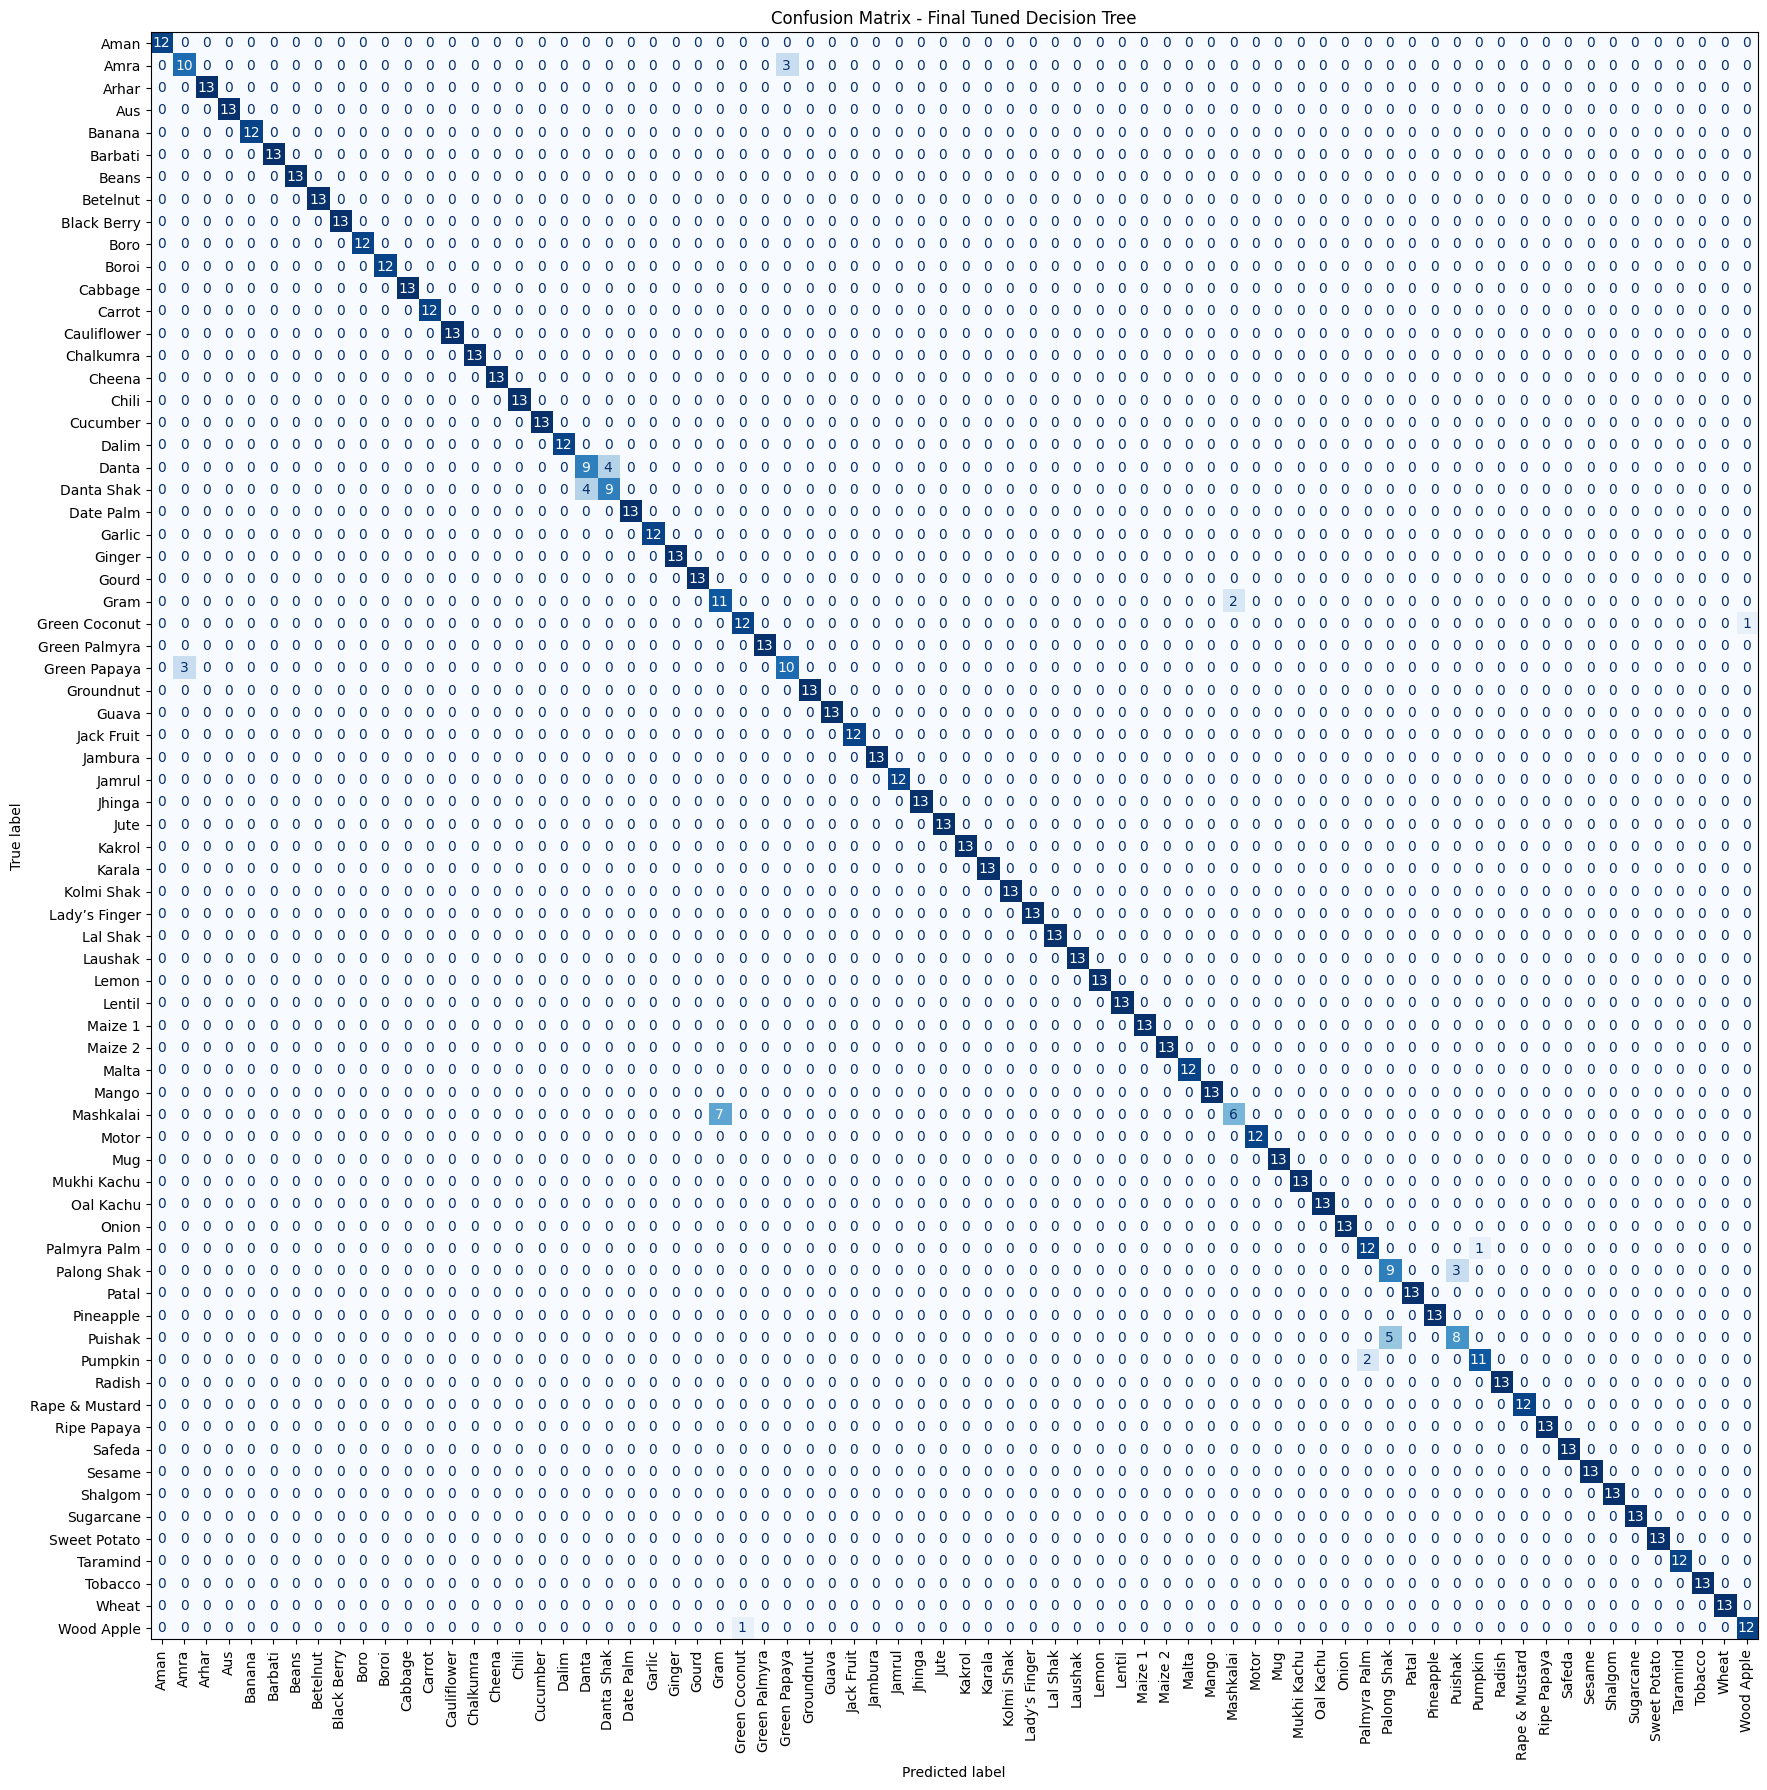

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_predictions, labels=best_dt.classes_)

plt.figure(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_dt.classes_
)
disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Confusion Matrix - Final Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_dt,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

5-Fold CV Scores: [0.97286296 0.96065129 0.95658073 0.96743555 0.95522388]
Mean CV Accuracy: 96.26%
Standard Deviation: 0.67%


In [44]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Logistic Regression",
        "Tuned Decision Tree"
    ],
    "Test Accuracy (%)": [
        95.44,
        95.12,
        30.59,
        5.64,
        12.80,
        96.10
    ]
})

print(final_results.to_string(index=False))

              Model  Test Accuracy (%)
      Decision Tree              95.44
      Random Forest              95.12
                KNN              30.59
                SVM               5.64
Logistic Regression              12.80
Tuned Decision Tree              96.10


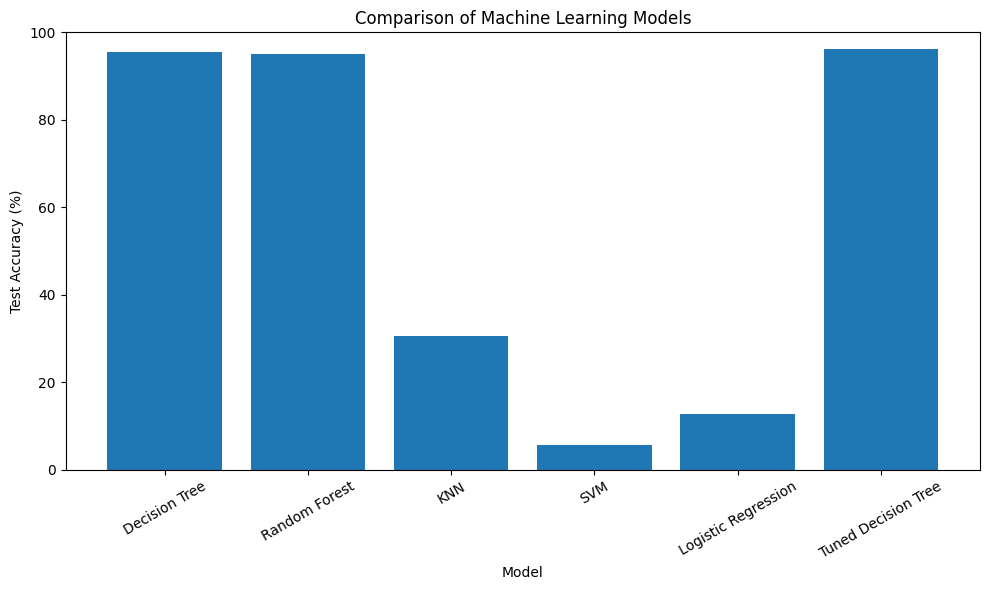

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(final_results["Model"], final_results["Test Accuracy (%)"])

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [46]:
import joblib

joblib.dump(best_dt, "final_crop_recommendation_model.pkl")
joblib.dump(preprocessor, "final_crop_preprocessor.pkl")

print("Final model and preprocessor saved successfully!")

Final model and preprocessor saved successfully!


In [47]:
import joblib

# Load saved model and preprocessor
final_model = joblib.load("final_crop_recommendation_model.pkl")
final_preprocessor = joblib.load("final_crop_preprocessor.pkl")

# Test input
test_input = pd.DataFrame([{
    "Area": 100,
    "AP Ratio": "1:1",
    "District": "Dhaka",
    "Season": "Rabi",
    "Avg Temp": 25,
    "Avg Humidity": 70,
    "Transplant": "November",
    "Growth": "December to March",
    "Harvest": "March",
    "Production": 500,
    "Max Temp": 30,
    "Min Temp": 20,
    "Max Relative Humidity": 85,
    "Min Relative Humidity": 55
}])

# Preprocess input
test_encoded = final_preprocessor.transform(test_input)

# Predict
final_prediction = final_model.predict(test_encoded)

print("Recommended Crop:", final_prediction[0])

Recommended Crop: Carrot


In [48]:
print("===== FINAL PROJECT RESULTS =====")
print("Dataset Size:", df.shape)
print("Number of Crop Classes:", df["Crop Name"].nunique())
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print(f"Final Test Accuracy: {best_dt_accuracy * 100:.2f}%")
print(f"Mean 5-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"CV Standard Deviation: {cv_scores.std() * 100:.2f}%")
print("Final Model: Tuned Decision Tree")
print("Model Status: Successfully Saved")
print("Prediction Test: Successful")

===== FINAL PROJECT RESULTS =====
Dataset Size: (4607, 15)
Number of Crop Classes: 72
Training Samples: 3685
Testing Samples: 922
Final Test Accuracy: 96.10%
Mean 5-Fold CV Accuracy: 96.26%
CV Standard Deviation: 0.67%
Final Model: Tuned Decision Tree
Model Status: Successfully Saved
Prediction Test: Successful
